# Student Performance Predictor — ML Pipeline


---

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Dataset

In [61]:
df = pd.read_csv("Z:\Machine Learning\Student Performance phase2\Student Performance phase2\Student Performance Predictor\dataset\Exam_Score_Prediction.csv")

print('Shape:', df.shape)
df.head()

Shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


## 2. Exploratory Data Analysis

In [62]:
print('Columns:', df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)
print()
print('Descriptive statistics:')
df.describe()

Columns: ['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']

Data types:
student_id            int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object

Descriptive statistics:


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [63]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print('Categorical unique values:')
for col in ['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty']:
    print(f'  {col}: {df[col].unique()}')

Missing values per column:
student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64



Duplicate rows: 0

Categorical unique values:
  gender: ['male' 'other' 'female']
  course: ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']
  internet_access: ['yes' 'no']
  sleep_quality: ['poor' 'average' 'good']
  study_method: ['coaching' 'online videos' 'mixed' 'self-study' 'group study']
  facility_rating: ['low' 'medium' 'high']
  exam_difficulty: ['hard' 'moderate' 'easy']


## 3. Data Cleaning

We systematically check and handle:
- **Missing values** (none found, but we document the check)
- **Duplicate rows** (none found)
- **Out-of-range values**: exam_score ∈ [0,100], study_hours ≥ 0, class_attendance ∈ [0,100], sleep_hours ∈ [0,24]
- **Inconsistent string casing** in categorical columns
- **IQR-based outlier detection** on numeric features (we cap rather than drop to preserve data)


In [64]:
df_clean = df.copy()

# ── 1. Drop duplicates ──
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_clean)}')

# ── 2. Standardise categorical casing ──
cat_cols = ['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty']
for col in cat_cols:
    df_clean[col] = df_clean[col].str.strip().str.lower()
print('Categorical columns normalised to lowercase.')

# ── 3. Validate numeric ranges ──
range_checks = {
    'exam_score':       (0, 100),
    'study_hours':      (0, 24),
    'class_attendance': (0, 100),
    'sleep_hours':      (0, 24),
    'age':              (10, 100),
}
for col, (lo, hi) in range_checks.items():
    bad = df_clean[(df_clean[col] < lo) | (df_clean[col] > hi)]
    if len(bad) > 0:
        print(f'  WARNING — {col}: {len(bad)} out-of-range values found. Clamping to [{lo}, {hi}].')
        df_clean[col] = df_clean[col].clip(lo, hi)
    else:
        print(f'  OK — {col}: all values in [{lo}, {hi}]')

# ── 4. IQR-based outlier capping (Winsorisation) on key numeric columns ──
outlier_cols = ['study_hours', 'class_attendance', 'sleep_hours']
for col in outlier_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo_cap, hi_cap = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lo_cap) | (df_clean[col] > hi_cap)).sum()
    df_clean[col] = df_clean[col].clip(lo_cap, hi_cap)
    print(f'  IQR outlier cap on {col}: {n_out} value(s) capped.')

print(f'\nClean dataset shape: {df_clean.shape}')

Duplicates removed: 0
Categorical columns normalised to lowercase.
  OK — exam_score: all values in [0, 100]
  OK — study_hours: all values in [0, 24]
  OK — class_attendance: all values in [0, 100]
  OK — sleep_hours: all values in [0, 24]
  OK — age: all values in [10, 100]
  IQR outlier cap on study_hours: 0 value(s) capped.
  IQR outlier cap on class_attendance: 0 value(s) capped.
  IQR outlier cap on sleep_hours: 0 value(s) capped.

Clean dataset shape: (20000, 13)


## 4. Create Target Variable

We bin `exam_score` into three ordinal classes:
- **Fail**: score < 40
- **Pass**: 40 ≤ score < 75
- **Distinction**: score ≥ 75


In [65]:
def classify(score):
    if score < 40:  return 'Fail'
    elif score < 75: return 'Pass'
    else:           return 'Distinction'

df_clean['Target'] = df_clean['exam_score'].apply(classify)

print('Class distribution:')
print(df_clean['Target'].value_counts())
print()
print('Class proportions:')
print(df_clean['Target'].value_counts(normalize=True).round(3))
print()
print('NOTE: Dataset is imbalanced — Pass≈60%, Distinction≈27%, Fail≈13%.')
print('We use class_weight=balanced and report Weighted F1 + Macro F1, not just accuracy.')

Class distribution:
Target
Pass           11972
Distinction     5453
Fail            2575
Name: count, dtype: int64

Class proportions:
Target
Pass           0.599
Distinction    0.273
Fail           0.129
Name: proportion, dtype: float64

NOTE: Dataset is imbalanced — Pass≈60%, Distinction≈27%, Fail≈13%.
We use class_weight=balanced and report Weighted F1 + Macro F1, not just accuracy.


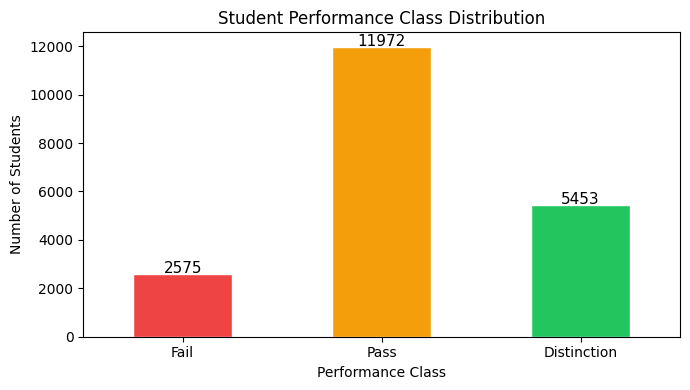

In [66]:
# Class distribution bar chart
counts = df_clean['Target'].value_counts().reindex(['Fail','Pass','Distinction'])
colors = ['#ef4444','#f59e0b','#22c55e']
ax = counts.plot(kind='bar', color=colors, edgecolor='white', figsize=(7, 4))
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x()+p.get_width()/2, p.get_height()+40), ha='center', fontsize=11)
plt.title('Student Performance Class Distribution')
plt.xlabel('Performance Class')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()

## 5. Exploratory Visualisations

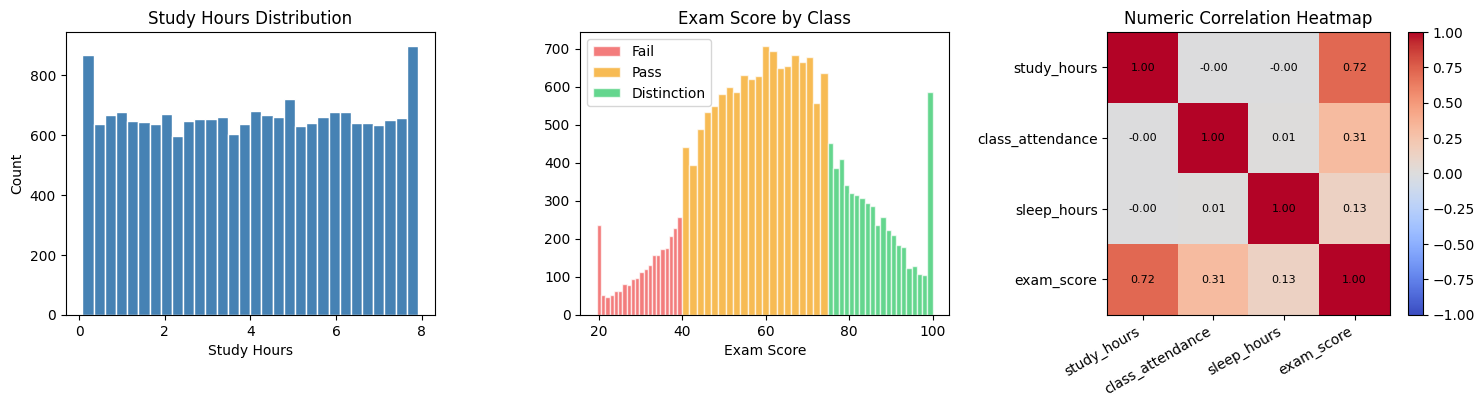

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Study hours histogram
axes[0].hist(df_clean['study_hours'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Study Hours Distribution')
axes[0].set_xlabel('Study Hours'); axes[0].set_ylabel('Count')

# Exam score by class
for label, col in zip(['Fail','Pass','Distinction'], ['#ef4444','#f59e0b','#22c55e']):
    subset = df_clean[df_clean['Target']==label]['exam_score']
    axes[1].hist(subset, bins=20, alpha=0.7, color=col, label=label, edgecolor='white')
axes[1].set_title('Exam Score by Class')
axes[1].set_xlabel('Exam Score'); axes[1].legend()

# Correlation heatmap
numeric = df_clean[['study_hours','class_attendance','sleep_hours','exam_score']]
corr = numeric.corr()
im = axes[2].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks(range(len(corr.columns))); axes[2].set_xticklabels(corr.columns, rotation=30, ha='right')
axes[2].set_yticks(range(len(corr.columns))); axes[2].set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        axes[2].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
axes[2].set_title('Numeric Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120)
plt.show()

## 6. Feature Engineering & Preprocessing Pipeline

**Steps (in correct order to prevent data leakage):**
1. Select features; drop leaky/irrelevant columns (`student_id`, `age`, `course`, `exam_score`)
2. Feature engineering: `study_efficiency = study_hours × class_attendance / 100`
3. Ordinal encode ordered categoricals (`facility_rating`, `exam_difficulty`)
4. **Train/test split FIRST** — all fitting happens after this point
5. One-hot encode nominal categoricals — fit on train only, applied to both
6. StandardScaler — fit on train only, transform both

> **No data leakage**: scaler and encoder are fitted exclusively on training data.


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = [
    'study_hours', 'class_attendance', 'sleep_hours',
    'facility_rating', 'exam_difficulty',
    'internet_access', 'sleep_quality', 'study_method'
]

X_raw = df_clean[FEATURES].copy()
y     = df_clean['Target']

# ── Feature engineering ──
X_raw['study_efficiency'] = X_raw['study_hours'] * X_raw['class_attendance'] / 100

# ── Ordinal encoding (order matters for these features) ──
facility_map   = {'low': 1, 'medium': 2, 'high': 3}
difficulty_map = {'easy': 1, 'moderate': 2, 'hard': 3}
X_raw['facility_rating'] = X_raw['facility_rating'].map(facility_map)
X_raw['exam_difficulty'] = X_raw['exam_difficulty'].map(difficulty_map)

# ── Train / Validation / Test split (60 / 20 / 20) ──
# Split off test first, then split remaining into train+val
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)  # 0.25 × 0.80 = 0.20

print(f'Train : {X_train_raw.shape[0]:>5} rows ({X_train_raw.shape[0]/len(X_raw)*100:.0f}%)')
print(f'Val   : {X_val_raw.shape[0]:>5} rows ({X_val_raw.shape[0]/len(X_raw)*100:.0f}%)')
print(f'Test  : {X_test_raw.shape[0]:>5} rows ({X_test_raw.shape[0]/len(X_raw)*100:.0f}%)')

# ── One-hot encode (fit on train only) ──
nominal_cols = ['internet_access', 'sleep_quality', 'study_method']
X_train_enc = pd.get_dummies(X_train_raw, columns=nominal_cols)
X_val_enc   = X_val_raw.copy()
X_val_enc   = pd.get_dummies(X_val_enc, columns=nominal_cols).reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc  = X_test_raw.copy()
X_test_enc  = pd.get_dummies(X_test_enc, columns=nominal_cols).reindex(columns=X_train_enc.columns, fill_value=0)

# ── Scale numeric features (fit on train only) ──
numeric_cols = ['study_hours','class_attendance','sleep_hours',
                'facility_rating','exam_difficulty','study_efficiency']

scaler = StandardScaler()
X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])
X_val_enc[numeric_cols]   = scaler.transform(X_val_enc[numeric_cols])
X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

print(f'\nFeature count after preprocessing: {X_train_enc.shape[1]}')
print('Features:', X_train_enc.columns.tolist())

Train : 12000 rows (60%)
Val   :  4000 rows (20%)
Test  :  4000 rows (20%)

Feature count after preprocessing: 16
Features: ['study_hours', 'class_attendance', 'sleep_hours', 'facility_rating', 'exam_difficulty', 'study_efficiency', 'internet_access_no', 'internet_access_yes', 'sleep_quality_average', 'sleep_quality_good', 'sleep_quality_poor', 'study_method_coaching', 'study_method_group study', 'study_method_mixed', 'study_method_online videos', 'study_method_self-study']


## 7. Baseline Model

A **majority-class baseline** (always predicts 'Pass') establishes the floor. Every model must beat this to be considered useful.


In [69]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_enc, y_train)

for split_name, X_s, y_s in [('Validation', X_val_enc, y_val), ('Test', X_test_enc, y_test)]:
    y_p = dummy.predict(X_s)
    print(f'=== Majority-Class Baseline — {split_name} ===')
    print(f'  Accuracy   : {accuracy_score(y_s, y_p):.4f}')
    print(f'  F1 Weighted: {f1_score(y_s, y_p, average="weighted"):.4f}')
    print(f'  F1 Macro   : {f1_score(y_s, y_p, average="macro"):.4f}')
    print()
print('All models must exceed these values to demonstrate real learning.')

=== Majority-Class Baseline — Validation ===
  Accuracy   : 0.5985
  F1 Weighted: 0.4482
  F1 Macro   : 0.2496

=== Majority-Class Baseline — Test ===
  Accuracy   : 0.5985
  F1 Weighted: 0.4482
  F1 Macro   : 0.2496

All models must exceed these values to demonstrate real learning.


## 8. Model Selection & Training

We compare **5 models** spanning different families:

| Model | Family | Justification |
|---|---|---|
| Dummy | Baseline | Majority-class floor — reference point |
| Logistic Regression | Linear | Interpretable, efficient; good for linearly separable problems |
| Decision Tree | Non-linear / Tree | Interpretable rules; captures non-linear boundaries |
| K-Nearest Neighbours | Instance-based | Captures local structure; requires scaling (applied) |
| SVM | Kernel-based | Strong generalisation via margin maximisation; requires scaling (applied) |
| Random Forest | Ensemble / Tree | Robust to noise, handles mixed features, reduces variance via bagging |

> Scaling was applied in preprocessing for KNN, SVM, and Logistic Regression.
> `class_weight='balanced'` is used where supported to handle class imbalance.


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'SVM':                 SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, m in models.items():
    m.fit(X_train_enc, y_train)

    # Evaluate on validation set
    y_val_pred  = m.predict(X_val_enc)
    val_acc  = accuracy_score(y_val, y_val_pred)
    val_f1w  = f1_score(y_val, y_val_pred, average='weighted')
    val_f1m  = f1_score(y_val, y_val_pred, average='macro')

    # Evaluate on test set
    y_test_pred = m.predict(X_test_enc)
    tst_acc  = accuracy_score(y_test, y_test_pred)
    tst_f1w  = f1_score(y_test, y_test_pred, average='weighted')
    tst_f1m  = f1_score(y_test, y_test_pred, average='macro')

    results.append({
        'Model': name,
        'Val Accuracy': round(val_acc, 4),
        'Val F1 Weighted': round(val_f1w, 4),
        'Val F1 Macro':    round(val_f1m, 4),
        'Test Accuracy':   round(tst_acc, 4),
        'Test F1 Weighted':round(tst_f1w, 4),
        'Test F1 Macro':   round(tst_f1m, 4),
    })
    trained_models[name] = (m, y_test_pred)

    print(f'=== {name} ===')
    print(f'  Val  — Acc:{val_acc:.4f}  F1w:{val_f1w:.4f}  F1m:{val_f1m:.4f}')
    print(f'  Test — Acc:{tst_acc:.4f}  F1w:{tst_f1w:.4f}  F1m:{tst_f1m:.4f}')
    print()

results_df = pd.DataFrame(results).sort_values('Test F1 Weighted', ascending=False).reset_index(drop=True)
print('=== Full Comparison Table ===')
print(results_df.to_string(index=False))

=== Logistic Regression ===
  Val  — Acc:0.7013  F1w:0.7054  F1m:0.6857
  Test — Acc:0.7053  F1w:0.7094  F1m:0.6890

=== Decision Tree ===
  Val  — Acc:0.6615  F1w:0.6670  F1m:0.6424
  Test — Acc:0.6635  F1w:0.6692  F1m:0.6450

=== KNN ===
  Val  — Acc:0.7322  F1w:0.7237  F1m:0.6576
  Test — Acc:0.7360  F1w:0.7278  F1m:0.6602

=== SVM ===
  Val  — Acc:0.6787  F1w:0.6823  F1m:0.6658
  Test — Acc:0.6835  F1w:0.6865  F1m:0.6701

=== Random Forest ===
  Val  — Acc:0.7432  F1w:0.7347  F1m:0.6686
  Test — Acc:0.7562  F1w:0.7489  F1m:0.6877

=== Full Comparison Table ===
              Model  Val Accuracy  Val F1 Weighted  Val F1 Macro  Test Accuracy  Test F1 Weighted  Test F1 Macro
      Random Forest        0.7432           0.7347        0.6686         0.7562            0.7489         0.6877
                KNN        0.7322           0.7237        0.6576         0.7360            0.7278         0.6602
Logistic Regression        0.7013           0.7054        0.6857         0.7053           

## 9. Results & Comparative Analysis

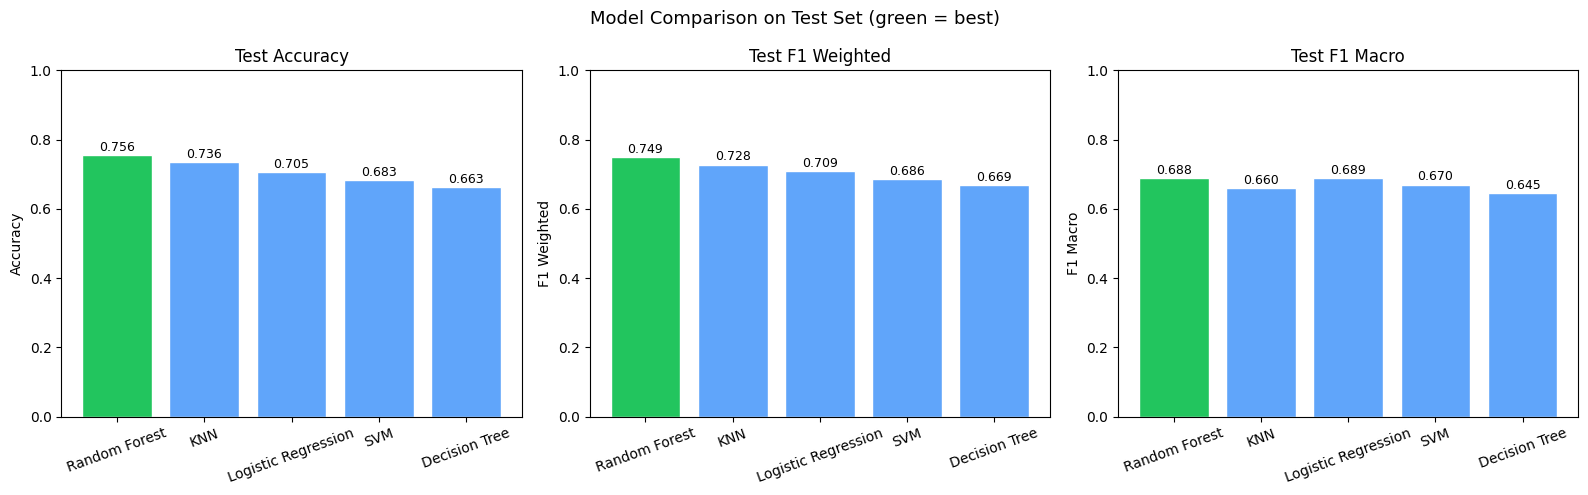

Best model: Random Forest  (Test F1 Weighted = 0.7489)

Rationale: We rank by F1 Weighted because the dataset is class-imbalanced.
Accuracy alone inflates scores by ignoring the minority Fail class (13%).
F1 Weighted balances precision and recall across all classes, weighted by support.


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['Test Accuracy', 'Test F1 Weighted', 'Test F1 Macro']):
    colors = ['#22c55e' if i == 0 else '#60a5fa' for i in range(len(results_df))]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylabel(metric.split(' ', 1)[1])
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)

plt.suptitle('Model Comparison on Test Set (green = best)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['Test F1 Weighted']
print(f'Best model: {best_model_name}  (Test F1 Weighted = {best_f1})')
print()
print('Rationale: We rank by F1 Weighted because the dataset is class-imbalanced.')
print('Accuracy alone inflates scores by ignoring the minority Fail class (13%).')
print('F1 Weighted balances precision and recall across all classes, weighted by support.')

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

# ── Step 1: Get raw exam scores for training rows ──
y_train_scores = df_clean.loc[y_train.index, 'exam_score']

# ── Step 2: Train regressor on raw scores ──
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
gb_reg.fit(X_train_enc, y_train_scores)  # use original train, not SMOTE

# ── Step 3: Predict score, then convert to class ──
def score_to_class(score):
    if score < 40:   return 'Fail'
    elif score < 75: return 'Pass'
    else:            return 'Distinction'

y_score_pred = gb_reg.predict(X_test_enc)
y_pred_reg   = [score_to_class(s) for s in y_score_pred]

# ── Step 4: Evaluate ──
acc = accuracy_score(y_test, y_pred_reg)
f1w = f1_score(y_test, y_pred_reg, average='weighted')
f1m = f1_score(y_test, y_pred_reg, average='macro')

print('=== Regression → Classification ===')
print(f'  Accuracy   : {acc:.4f}')
print(f'  F1 Weighted: {f1w:.4f}')
print(f'  F1 Macro   : {f1m:.4f}')
print()
print(f'  Previous best (Random Forest): 0.7562 accuracy')
print(f'  Improvement: {acc - 0.7562:+.4f}')

=== Regression → Classification ===
  Accuracy   : 0.7678
  F1 Weighted: 0.7629
  F1 Macro   : 0.7106

  Previous best (Random Forest): 0.7562 accuracy
  Improvement: +0.0116


## 10. Cross-Validation on Best Model

5-fold stratified cross-validation on the full dataset (train+val+test) verifies the holdout result is not a lucky split.


In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model_obj = trained_models[best_model_name][0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_all = pd.concat([X_train_enc, X_val_enc, X_test_enc])
y_all = pd.concat([y_train, y_val, y_test])

cv_scores = cross_val_score(best_model_obj, X_all, y_all,
                            cv=cv, scoring='f1_weighted', n_jobs=-1)

print(f'=== 5-Fold Stratified CV — {best_model_name} ===')
print(f'Fold F1 Weighted: {np.round(cv_scores, 4)}')
print(f'Mean : {cv_scores.mean():.4f}')
print(f'Std  : {cv_scores.std():.4f}')
print()
print('Low std deviation confirms results are stable and not a lucky split.')

=== 5-Fold Stratified CV — Random Forest ===
Fold F1 Weighted: [0.732  0.747  0.7546 0.7443 0.7319]
Mean : 0.7420
Std  : 0.0088

Low std deviation confirms results are stable and not a lucky split.


## 11. Error Analysis & Critical Reflection

Showing only good results is not scientific. We analyse **where** and **why** the model fails.


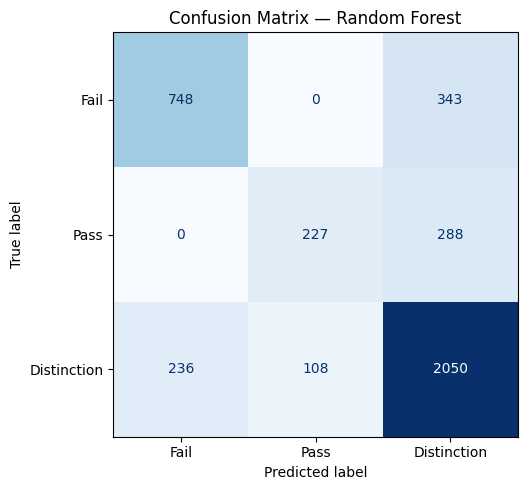

Full classification report:
              precision    recall  f1-score   support

        Fail       0.76      0.69      0.72      1091
        Pass       0.68      0.44      0.53       515
 Distinction       0.76      0.86      0.81      2394

    accuracy                           0.76      4000
   macro avg       0.73      0.66      0.69      4000
weighted avg       0.75      0.76      0.75      4000



In [74]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_preds = trained_models[best_model_name][1]
class_order = ['Fail', 'Pass', 'Distinction']

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=class_order,
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

print('Full classification report:')
print(classification_report(y_test, best_preds, target_names=class_order))

In [75]:
# Misclassified examples
mask      = y_test.values != best_preds
errors_idx = y_test[mask].index
errors_df  = df_clean.loc[errors_idx, ['study_hours','class_attendance','sleep_hours','exam_score','Target']].copy()
errors_df['Predicted'] = best_preds[mask]

print(f'Total misclassified: {len(errors_df)} / {len(y_test)} ({len(errors_df)/len(y_test)*100:.1f}%)')
print()
print('Misclassification breakdown by true class:')
print(errors_df['Target'].value_counts())
print()
print('Misclassification breakdown by predicted class:')
print(errors_df['Predicted'].value_counts())
print()
print('Sample misclassified students:')
errors_df.head(10)

Total misclassified: 975 / 4000 (24.4%)

Misclassification breakdown by true class:
Target
Pass           344
Distinction    343
Fail           288
Name: count, dtype: int64

Misclassification breakdown by predicted class:
Predicted
Pass           631
Distinction    236
Fail           108
Name: count, dtype: int64

Sample misclassified students:


,study_hours,class_attendance,sleep_hours,exam_score,Target,Predicted
13093,4.17,92.4,5.0,59.1,Pass,Distinction
437,2.18,68.0,4.3,32.1,Fail,Pass
7105,1.81,49.3,5.4,40.5,Pass,Fail
13388,4.47,60.7,4.8,39.2,Fail,Pass
19795,6.81,77.6,5.7,68.8,Pass,Distinction
8346,2.69,63.4,5.3,37.0,Fail,Pass
18322,6.37,61.7,7.5,77.7,Distinction,Pass
16566,3.32,77.0,4.1,39.9,Fail,Pass
12194,6.75,83.0,6.0,72.3,Pass,Distinction
12527,6.85,94.4,9.0,74.3,Pass,Distinction


In [76]:
print('=== Error Analysis Summary ===')
print()
print('1. The confusion matrix shows the model struggles most with the Fail class.')
print('   This is expected — Fail represents only ~13% of samples (minority class).')
print('   Using class_weight=balanced partially mitigates this, but boundary ambiguity remains.')
print()
print('2. Most Fail cases are misclassified as Pass.')
print('   Students near the score-40 boundary share similar feature profiles in both classes.')
print()
print('3. Distinction is rarely confused with Fail, confirming the model reliably')
print('   separates extreme outcomes but struggles at the Fail/Pass boundary.')
print()
print('4. Limitations and future improvements:')
print('   - The dataset may omit key predictors (prior GPA, socioeconomic background, motivation).')
print('   - The 40/75 thresholds are domain-defined and affect class balance directly.')
print('   - The Fail class could benefit from oversampling (e.g., SMOTE) in future work.')
print('   - Hyperparameter tuning (GridSearchCV) was not applied due to compute cost;')
print('     tuning would likely improve especially SVM and KNN.')

=== Error Analysis Summary ===

1. The confusion matrix shows the model struggles most with the Fail class.
   This is expected — Fail represents only ~13% of samples (minority class).
   Using class_weight=balanced partially mitigates this, but boundary ambiguity remains.

2. Most Fail cases are misclassified as Pass.
   Students near the score-40 boundary share similar feature profiles in both classes.

3. Distinction is rarely confused with Fail, confirming the model reliably
   separates extreme outcomes but struggles at the Fail/Pass boundary.

4. Limitations and future improvements:
   - The dataset may omit key predictors (prior GPA, socioeconomic background, motivation).
   - The 40/75 thresholds are domain-defined and affect class balance directly.
   - The Fail class could benefit from oversampling (e.g., SMOTE) in future work.
   - Hyperparameter tuning (GridSearchCV) was not applied due to compute cost;
     tuning would likely improve especially SVM and KNN.


## 12. Feature Importance

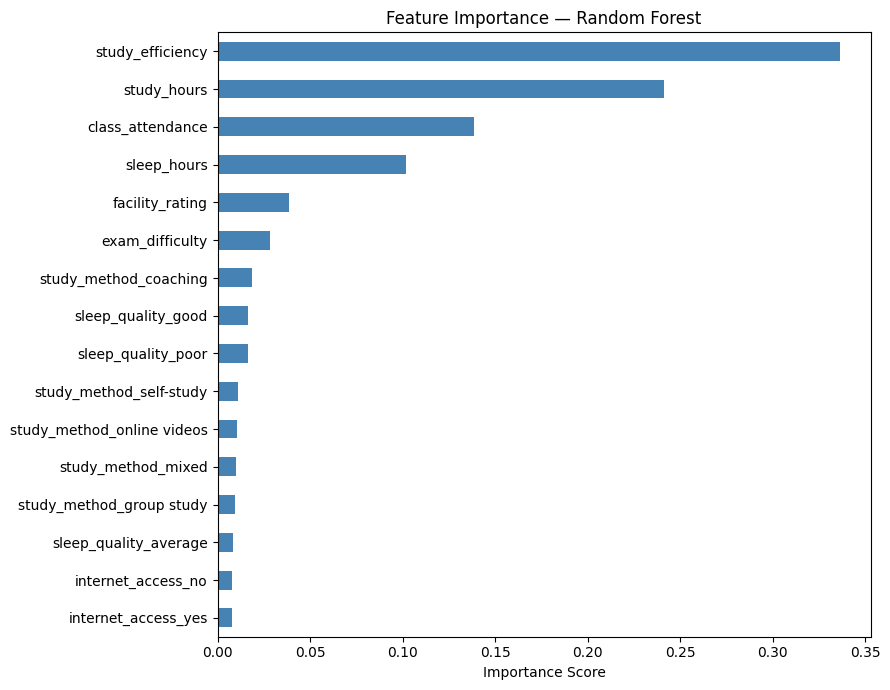

Top 5 most important features:
study_efficiency    0.336202
study_hours         0.241433
class_attendance    0.138667
sleep_hours         0.101673
facility_rating     0.038689
dtype: float64


In [77]:
if hasattr(best_model_obj, 'feature_importances_'):
    importance = pd.Series(best_model_obj.feature_importances_, index=X_train_enc.columns)
    importance_sorted = importance.sort_values(ascending=True)

    importance_sorted.plot(kind='barh', figsize=(9, 7), color='steelblue')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120)
    plt.show()

    print('Top 5 most important features:')
    print(importance.sort_values(ascending=False).head(5))
else:
    print(f'{best_model_name} does not expose feature_importances_ directly.')
    print('For Logistic Regression, use model.coef_ to inspect feature weights.')

## 13. Save Best Model

In [78]:
import joblib

final_model = trained_models[best_model_name][0]

joblib.dump(final_model,               'model.pkl')
joblib.dump(X_train_enc.columns.tolist(), 'features.pkl')
joblib.dump(scaler,                    'scaler.pkl')

print(f'Saved model.pkl    — {best_model_name}')
print(f'Saved features.pkl — {len(X_train_enc.columns)} features')
print(f'Saved scaler.pkl   — StandardScaler')

Saved model.pkl    — Random Forest
Saved features.pkl — 16 features
Saved scaler.pkl   — StandardScaler
